This is for simple, single-colored echograms, that display only what was marked in LSSS as:
1) He/Sp (fish schools)
2) Whiting (individual fish)
3) Other (thermocline/halocline)

This creates a clear transect with depth on the y-axis and timestamp on the x-axis (note: the length traveled or position is not marked here. To know where the ship was, check HFlog). 

The echogram should display the bottom, the fish, and the thermocline in different colors :)

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

%matplotlib inline

In [49]:
INPUT_PATH = r"C:\Users\tilde\Documents\LSSS\ListUserFile16__F038000_T1_0612.txt"

In [50]:
COLUMN_NAMES = [
    'YEAR', 'MO', 'DA', 'UTC', 'LOG1', 'LOG2', 'LAT', 'LON',
    'BDMIN', 'BDMAX', 'OBJECT', 'CH', 'PDMIN', 'PDMAX', 'PDMEAN',
    'UPINLM', 'OTHER', 'WHITE', 'OtPl', 'HeSp', 'TOTAL',
]


def load_lsss_file(path):
    df = pd.read_csv(path, sep=r'\s+', skiprows=1, names=COLUMN_NAMES)
    df['datetime'] = pd.to_datetime(
        df['YEAR'].astype(str) + '-' +
        df['MO'].astype(str).str.zfill(2) + '-' +
        df['DA'].astype(str).str.zfill(2) + ' ' + df['UTC']
    )
    return df


df = load_lsss_file(INPUT_PATH)
df.head()


,YEAR,MO,DA,UTC,LOG1,LOG2,LAT,LON,BDMIN,BDMAX,...,PDMIN,PDMAX,PDMEAN,UPINLM,OTHER,WHITE,OtPl,HeSp,TOTAL,datetime
0,2026,6,12,07:01:29,3515.344,3516.344,55.74634,12.71607,10.1,10.2,...,0,0,0.2,-0.2,0.0,0.0,0.0,0.0,NaN,2026-06-12 07:01:29
1,2026,6,12,07:01:29,3515.344,3516.344,55.74634,12.71607,10.1,10.2,...,0,1,0.8,-0.2,0.0,0.0,0.0,0.0,NaN,2026-06-12 07:01:29
2,2026,6,12,07:01:29,3515.344,3516.344,55.74634,12.71607,10.1,10.2,...,1,2,1.2,-0.2,0.0,0.0,0.0,0.0,NaN,2026-06-12 07:01:29
3,2026,6,12,07:01:29,3515.344,3516.344,55.74634,12.71607,10.1,10.2,...,2,2,1.8,-0.2,0.0,0.0,0.0,0.0,NaN,2026-06-12 07:01:29
4,2026,6,12,07:01:29,3515.344,3516.344,55.74634,12.71607,10.1,10.2,...,2,2,2.2,-0.2,0.0,0.0,0.0,0.0,NaN,2026-06-12 07:01:29


In [ ]:
def build_grid(df):
    times = sorted(df['datetime'].unique())
    time_index = {t: i for i, t in enumerate(times)}
    n_time = len(times)
    n_depth = df['CH'].max()

    other = np.full((n_depth, n_time), np.nan)
    white = np.full((n_depth, n_time), np.nan)
    hesp = np.full((n_depth, n_time), np.nan)

    t_idx = df['datetime'].map(time_index).values
    ch_idx = (df['CH'] - 1).values  

    other[ch_idx, t_idx] = df['OTHER'].values
    white[ch_idx, t_idx] = df['WHITE'].values
    hesp[ch_idx, t_idx] = df['HeSp'].values

    
    depth_per_ch = df.groupby('CH')['PDMEAN'].mean().sort_index().values

    stacked = np.stack([other, white, hesp])  

    
    visited = ~np.isnan(stacked).all(axis=0)
    stacked_filled = np.where(np.isnan(stacked), 0, stacked)

    
    has_detection = stacked_filled.max(axis=0) > 0
    dominant = np.argmax(stacked_filled, axis=0) + 1
    category = np.where(has_detection, dominant, 0).astype(float)
    category = np.where(visited, category, np.nan) 

    
    max_sv = stacked_filled.max(axis=0)
    with np.errstate(divide='ignore'):
        max_sv_db = 10 * np.log10(np.where(max_sv > 0, max_sv, np.nan))

    return category, max_sv_db, depth_per_ch, np.array(times)


category, sv_db, depth, times = build_grid(df)
print(f"Grid shape (depth x time): {category.shape}")


Grid shape (depth x time): (36, 3601)


In [ ]:
CATEGORY_COLORS = {
    1: (0.55, 0.55, 0.55),   # OTHER (thermocline)
    2: (0.20, 0.45, 0.85),   # WHITE (individual fish)
    3: (0.75, 0.10, 0.10),   # He/Sp (schools)
}
CATEGORY_LABELS = {
    1: 'Other (thermocline/halocline)',
    2: 'Whiting (individual fish)',
    3: 'Herring/sprat (schools)',
}
NO_DETECT_COLOR = (1.00, 1.00, 1.00)   # background
SEAFLOOR_COLOR = (0.65, 0.55, 0.40)    

TITLE = "Echogram of detected fish (day 4)"
FIGSIZE = (16, 6)


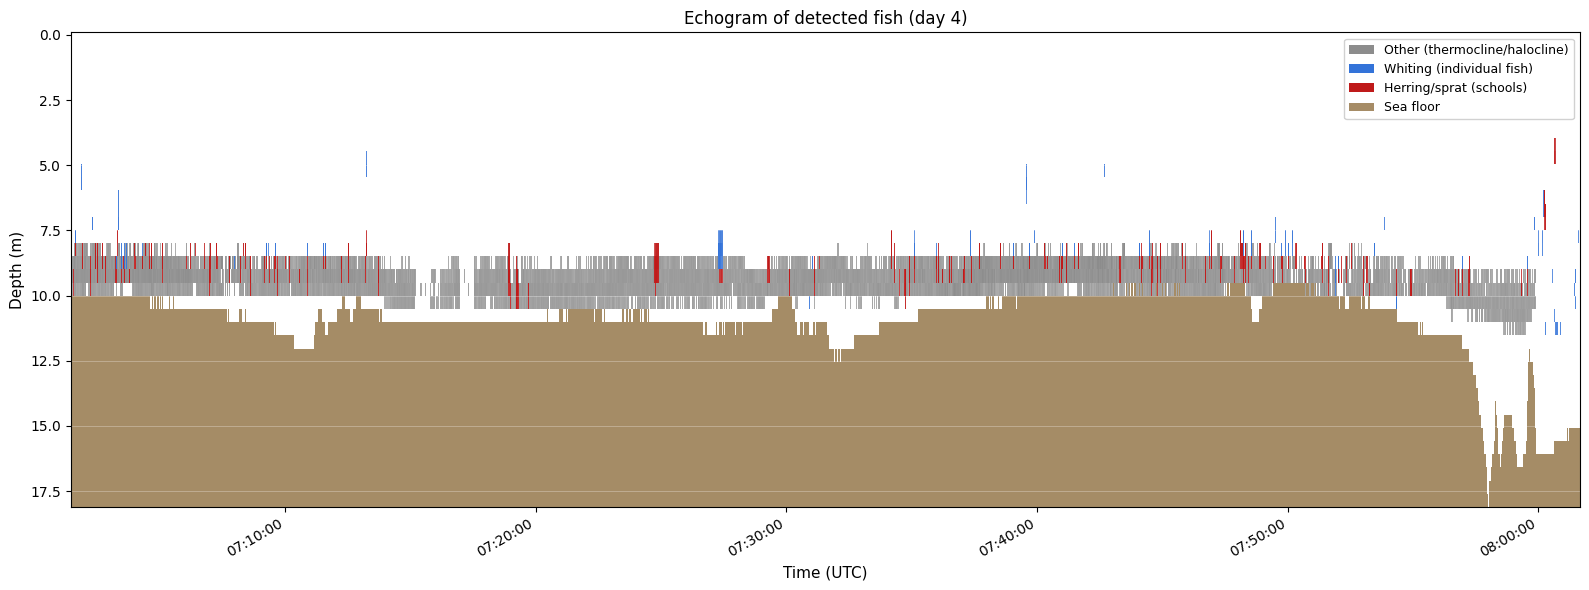

In [ ]:
def render_echogram(category, sv_db, depth, times, title, colors, labels,
                     no_detect_color, seafloor_color, figsize):
    n_depth, n_time = category.shape

    depth_step = np.median(np.diff(depth))
    depth_edges = np.concatenate([depth - depth_step / 2,
                                   [depth[-1] + depth_step / 2]])

  
    time_nums = mdates.date2num(times)
    time_step = np.median(np.diff(time_nums))
    time_edges = np.concatenate([time_nums - time_step / 2,
                                  [time_nums[-1] + time_step / 2]])

   
    finite_db = sv_db[np.isfinite(sv_db)]
    vmin, vmax = np.nanpercentile(finite_db, [2, 98])
    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)

    
    img = np.ones((n_depth, n_time, 3))
    img[np.isnan(category)] = seafloor_color
    img[category == 0] = no_detect_color

    for cat_id, base_color in colors.items():
        mask = (category == cat_id)
        if not np.any(mask):
            continue
        intensities = norm(sv_db[mask])
        base = np.array(base_color)
        bg = np.array(no_detect_color)
        light = bg * 0.3 + base * 0.7
        blended = (light[None, :] * (1 - intensities[:, None]) +
                   base[None, :] * intensities[:, None])
        img[mask] = blended

    fig, ax = plt.subplots(figsize=figsize)
    extent = [time_edges[0], time_edges[-1], depth_edges[-1], depth_edges[0]]
    ax.imshow(img, aspect='auto', extent=extent, interpolation='nearest')

    ax.set_ylabel('Depth (m)', fontsize=11)
    ax.set_xlabel('Time (UTC)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='y', color='white', linewidth=0.4, alpha=0.5)

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    fig.autofmt_xdate()

    legend_patches = [mpatches.Patch(facecolor=colors[k], label=labels[k]) for k in [1, 2, 3]]
    legend_patches.append(mpatches.Patch(facecolor=seafloor_color, label='Sea floor'))
    ax.legend(handles=legend_patches, loc='upper right', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.show()


render_echogram(category, sv_db, depth, times, TITLE, CATEGORY_COLORS, CATEGORY_LABELS,
                NO_DETECT_COLOR, SEAFLOOR_COLOR, FIGSIZE)
